In [32]:
from mdp.base_config import BaseConfig
import numpy as np
import matplotlib.pyplot as plt
from algorithms.sgns_sarsa.n_step_sarsa_mc import NStepSarsaMC, MCConfig, MountainCarSARSAHelpers
from mdp.mountaincar.mountaincar import MountainCarMDP

base_config = BaseConfig(42)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
def _mc_feature(env):
    """Feature builder for MountainCar's continuous state space."""
    obs = env.env.observation_space
    l = np.asarray(obs.low, dtype=np.float64)
    h = np.asarray(obs.high, dtype=np.float64)
    r = np.where(h - l == 0, 1.0, h - l)

    def feature_fn(state):
        """Feature function for MountainCar's continuous state space."""
        a = np.asarray(state, dtype=np.float64)
        n = (a - l) / r * 2.0 - 1.0
        p, v = n
        a_0 = a[0]
        return np.array(
            [
                1.0,
                p,
                v,
                p * v,
                p**2,
                v**2,
                np.sin(3.0 * a_0),
                np.cos(3.0 * a_0),
            ],
            dtype=np.float64,
        )

    return feature_fn, 8

def _mountaincar_state_grid(env, *, pos_bins=40, vel_bins=40):
    """Returns discrete MountainCar states for policy inspection."""
    obs_space = env.env.observation_space
    pos_vals = np.linspace(obs_space.low[0], obs_space.high[0], pos_bins)
    vel_vals = np.linspace(obs_space.low[1], obs_space.high[1], vel_bins)
    return [(float(p), float(v)) for p in pos_vals for v in vel_vals]

In [33]:
mc = MountainCarMDP(seed=42)
mc_helper = MountainCarSARSAHelpers()
feature_fn, num_features = _mc_feature(env=mc)
feature_fn_tc, num_features_tc = mc_helper.make_tile_coding_feature_fn(mc, num_tilings=8, num_tiles=8)


In [37]:
sarsa_mc_config = MCConfig(weight_init_choice="optimistic", optimistic_value=10, epsilon=0.1)
sarsa_agent = NStepSarsaMC(config=sarsa_mc_config, env=mc, feature_fn=feature_fn_tc, num_features=num_features_tc, base_config=base_config)

In [38]:
sarsa_agent.run(num_episodes=1000, alpha=0.1, n_steps=5)

Running SARSA Episodes:   0%|          | 0/1000 [00:00<?, ?it/s]

1000


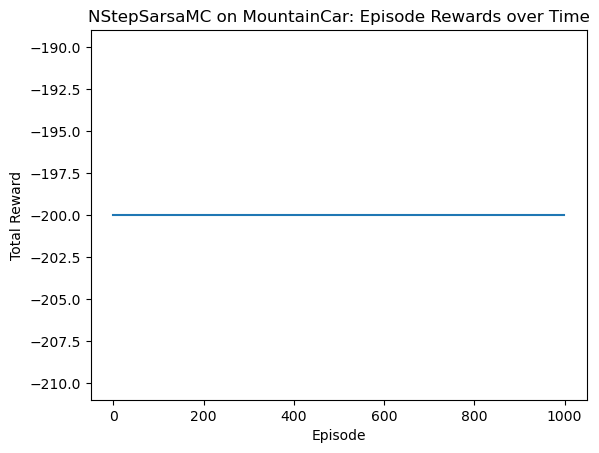

In [39]:
episode_reward_history = sarsa_agent.episode_rewards
print(len(episode_reward_history))
plt.plot(episode_reward_history)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("NStepSarsaMC on MountainCar: Episode Rewards over Time")
plt.show()